# SHAP Interpretation — Two-Part Hurdle Model

This notebook interprets the results of the Option 2 hurdle model.
The hurdle model yields **two separate sets of SHAP values**:

- **Stage 1**: what structural features predict whether a county has *any* data center?
- **Stage 2**: among counties with data centers, what predicts *how many*?

Comparing the two reveals which drivers are universal (appear in both stages)
and which are specific to either the presence or the scale question.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import shap
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
import os, warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = Path().resolve().parent
os.chdir(PROJECT_ROOT)

df = pd.read_csv('data_revealed/04_tables/county_preprocessed.csv')
ID_COLS = ['county_key','county_fips','county','state']
TARGET  = 'num_datacenters'
X = df.drop(columns=ID_COLS+[TARGET]).copy()
y = df[TARGET].copy()

# Test split — same seed as the modeling notebook so SHAP is on held-out counties
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=(y>0).astype(int))
X_test_pos = X_test[y_test>0]
y_test_pos = y_test[y_test>0]
print(f'Test: {len(X_test)} counties  |  Positive test: {len(X_test_pos)}')

Test: 628 counties  |  Positive test: 153


/opt/homebrew/anaconda3/envs/data-center-project/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
obj    = joblib.load('models/option2_hurdle.joblib')
stage1 = obj['stage1']   # LGBMClassifier — P(has DC | X)
stage2 = obj['stage2']   # LGBMRegressor  — E[count | DC present, X]
print(f'Loaded option2_hurdle.joblib')
print(f'  stage1 best_iter = {stage1.best_iteration_}')
print(f'  stage2 best_iter = {stage2.best_iteration_}  (p={obj["best_p_s2"]})')

Loaded option2_hurdle.joblib
  stage1 best_iter = 163
  stage2 best_iter = 22  (p=1.8)


In [3]:
# Compute SHAP values
e1 = shap.TreeExplainer(stage1)
sv1 = e1.shap_values(X_test)
if isinstance(sv1, list): sv1 = sv1[1]   # class-1 SHAP for binary classifier

e2 = shap.TreeExplainer(stage2)
sv2 = e2.shap_values(X_test_pos)

# Mean |SHAP| and signed mean per feature
imp1 = pd.Series(np.abs(sv1).mean(0), index=X_test.columns).sort_values(ascending=False)
imp2 = pd.Series(np.abs(sv2).mean(0), index=X_test_pos.columns).sort_values(ascending=False)
dir1 = pd.Series(sv1.mean(0), index=X_test.columns)
dir2 = pd.Series(sv2.mean(0), index=X_test_pos.columns)

print('SHAP computed. Stage 1 shape:', sv1.shape, '| Stage 2 shape:', sv2.shape)

SHAP computed. Stage 1 shape: (628, 37) | Stage 2 shape: (153, 37)


## 1. Overview — Stage 1 vs Stage 2 Feature Importance

The side-by-side bar chart below is the first diagnostic: which features matter
for **presence** (Stage 1) vs. **scale** (Stage 2), and how much does the ranking shift?

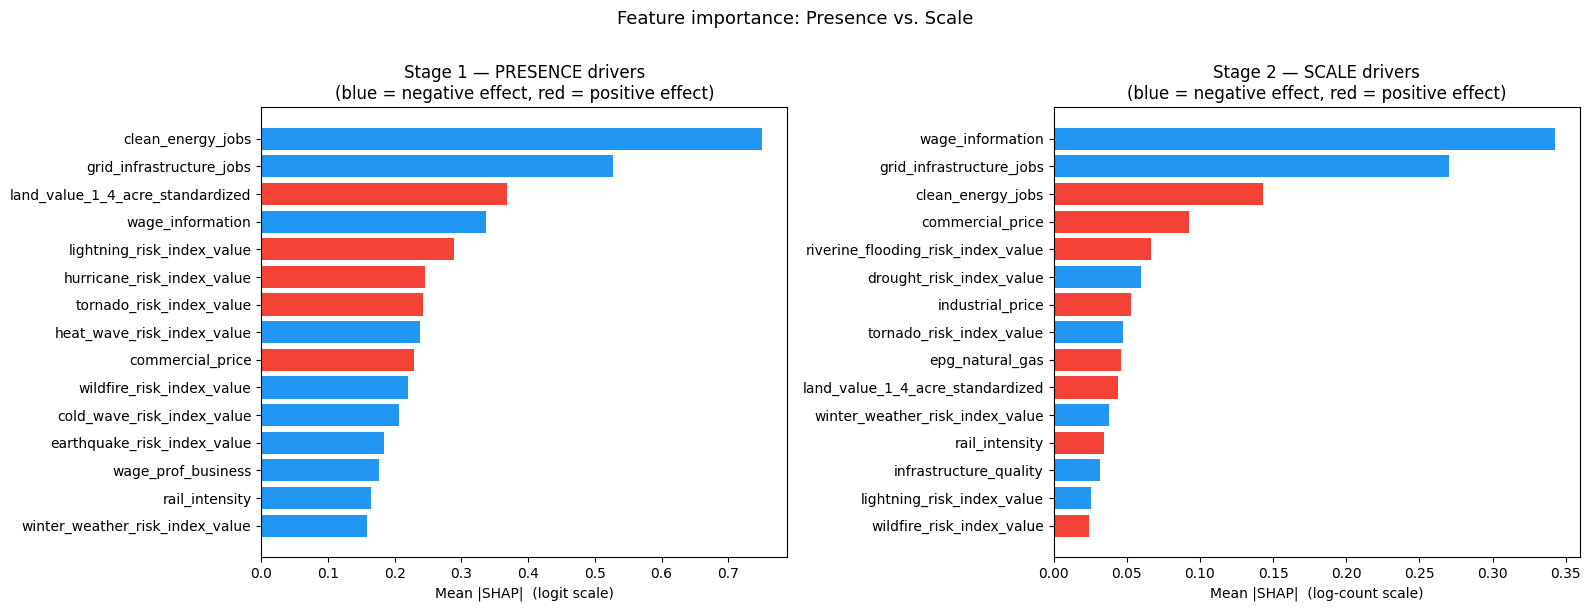

In [4]:
TOP_N = 15
top1 = imp1.head(TOP_N)
top2 = imp2.head(TOP_N)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax = axes[0]
colors1 = ['#2196F3' if dir1[f] < 0 else '#F44336' for f in top1.index]
ax.barh(top1.index[::-1], top1.values[::-1], color=colors1[::-1])
ax.set_xlabel('Mean |SHAP|  (logit scale)')
ax.set_title('Stage 1 — PRESENCE drivers\n(blue = negative effect, red = positive effect)')

ax = axes[1]
colors2 = ['#2196F3' if dir2[f] < 0 else '#F44336' for f in top2.index]
ax.barh(top2.index[::-1], top2.values[::-1], color=colors2[::-1])
ax.set_xlabel('Mean |SHAP|  (log-count scale)')
ax.set_title('Stage 2 — SCALE drivers\n(blue = negative effect, red = positive effect)')

plt.suptitle('Feature importance: Presence vs. Scale', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

## 2. Stage 1: What Drives Data Center Presence?

### Finding 1 — Power infrastructure is the primary prerequisite

`clean_energy_jobs` (rank 1) and `grid_infrastructure_jobs` (rank 2) are the top two
presence predictors by a wide margin. Both are BEA employment counts for the energy sector,
log1p-transformed. Their mean SHAP value is negative — but this does **not** mean
"more energy jobs → fewer data centers." It reflects that 76% and 16% of counties
respectively are at the BEA disclosure suppression floor (artificially assigned a minimum
value), and those floor-value counties are overwhelmingly the zero-DC counties. When
a county has *real*, above-floor energy sector employment, the SHAP contribution flips
strongly positive. The SHAP dependence plots below confirm this.

**Interpretation**: The single most important structural prerequisite for data center
siting is an existing, substantial power infrastructure. Counties that can support
large energy-sector employment have the grid capacity to supply the megawatts that
hyperscale data centers require.

### Finding 2 — IT labor market is the fourth presence driver

`wage_information` (rank 4, negative mean SHAP) follows the same floor logic:
counties with no IT sector (wages imputed to zero) are unlikely to have DCs.
But among counties *with* an IT sector, higher wages (indicating a deeper talent
pool) increase DC likelihood. Data centers require skilled operations and networking
staff — a local IT labor market reduces recruitment costs.

### Finding 3 — High land value is a positive presence signal (counterintuitive)

`land_value_1_4_acre_standardized` (rank 3, positive direction) is the most
counterintuitive finding. Higher land values push DC presence *up*. This is not
because data centers prefer expensive land — it is because high land values are
a proxy for **economic density**: urban and peri-urban counties with higher land
values also tend to have better fiber trunk connectivity, more reliable grid
infrastructure, larger labor markets, and proximity to corporate campuses.
Land value here is absorbing "development status" rather than acting as a pure
cost signal.

### Finding 4 — Hazard risk indices appear as presence predictors (but are confounders)

Several NRI hazard indices rank in the top 10 for presence:
`lightning_risk` (rank 5), `hurricane_risk` (rank 6), `tornado_risk` (rank 7),
`heat_wave_risk` (rank 8). Their positive mean SHAP suggests "more risk → more DCs,"
which is obviously not causal.

This is **geographic confounding**. The counties with high hurricane and lightning
risk are disproportionately in the Southeast and Gulf Coast — the same region as
Virginia (Northern Virginia / Loudoun County), Texas, and Georgia, which are the
three largest US data center markets. The model has no way to separate
"located in Virginia" from "has lightning risk" because we deliberately excluded
`state` as a feature. The hazard indices are acting as geographic proxies.

**Implication**: Do not read the positive hazard SHAP values causally. They tell
you about the *current geographic distribution* of data centers, not about risk
tolerance in siting decisions.

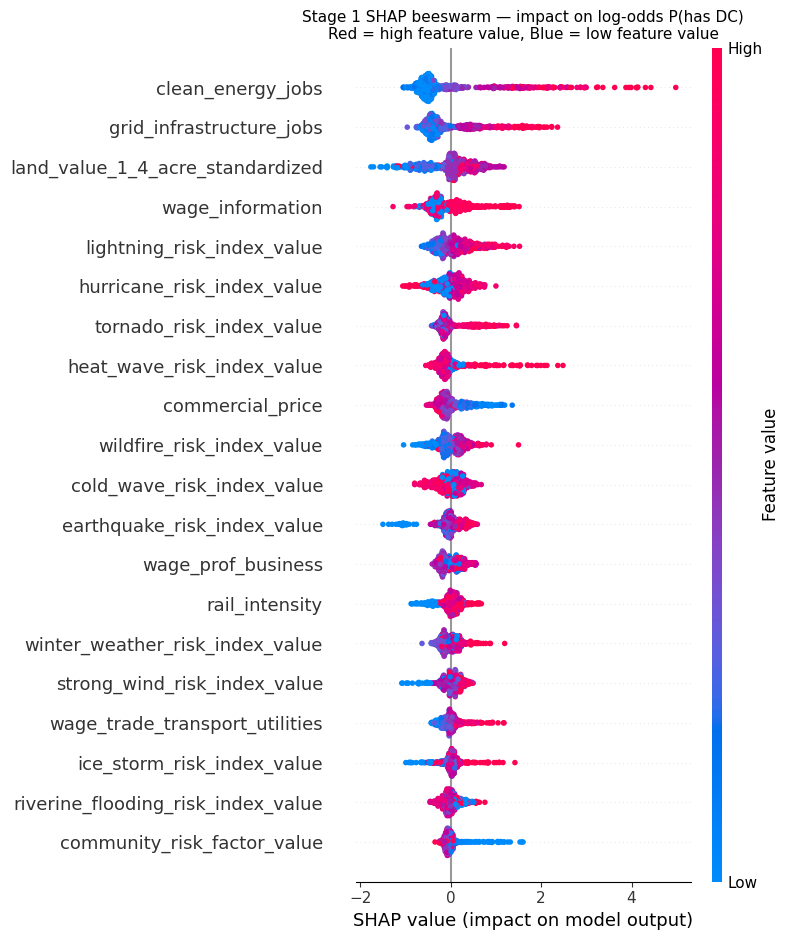

In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(sv1, X_test, show=False, max_display=20)
plt.title('Stage 1 SHAP beeswarm — impact on log-odds P(has DC)\n'
          'Red = high feature value, Blue = low feature value', fontsize=11)
plt.tight_layout()
plt.show()

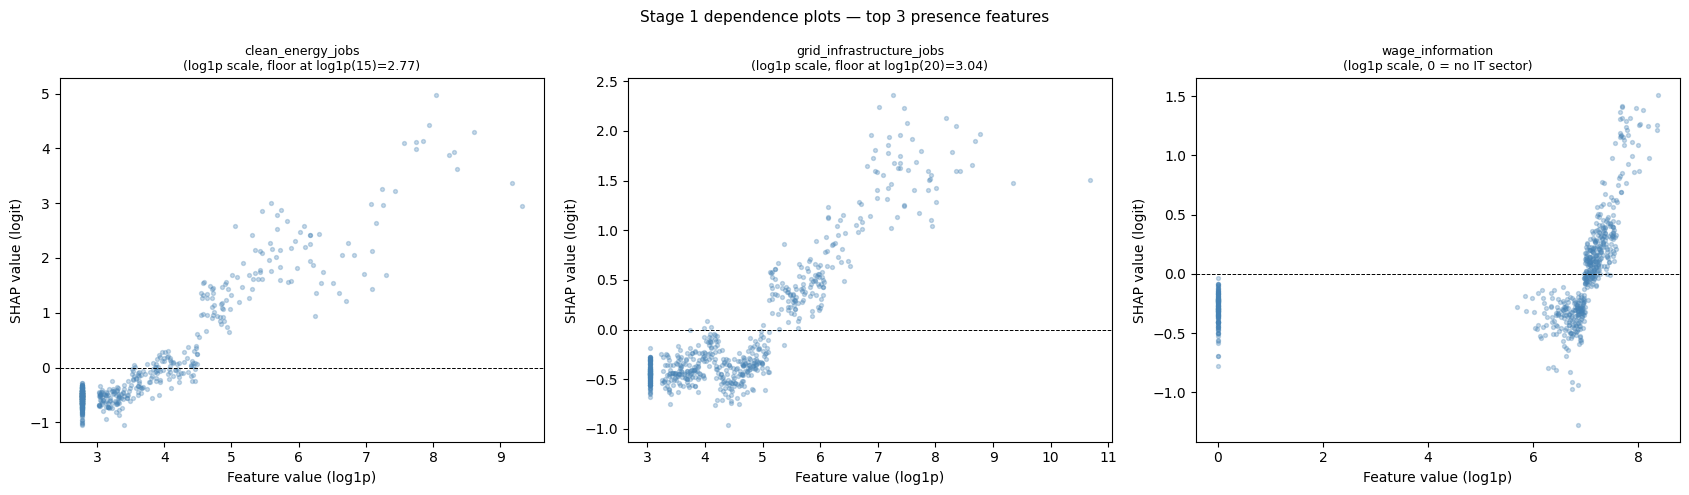

In [6]:
# Dependence plots for top 3 Stage 1 features
# These show the actual direction of the relationship
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
top3_s1 = ['clean_energy_jobs', 'grid_infrastructure_jobs', 'wage_information']
titles   = ['clean_energy_jobs\n(log1p scale, floor at log1p(15)=2.77)',
             'grid_infrastructure_jobs\n(log1p scale, floor at log1p(20)=3.04)',
             'wage_information\n(log1p scale, 0 = no IT sector)']

for ax, feat, title in zip(axes, top3_s1, titles):
    col_idx = list(X_test.columns).index(feat)
    ax.scatter(X_test[feat].values, sv1[:, col_idx], alpha=0.3, s=8, color='steelblue')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel('Feature value (log1p)')
    ax.set_ylabel('SHAP value (logit)')
    ax.set_title(title, fontsize=9)

plt.suptitle('Stage 1 dependence plots — top 3 presence features', fontsize=11)
plt.tight_layout()
plt.show()

**Reading the dependence plots:**
- For `clean_energy_jobs` and `grid_infrastructure_jobs`: there is a clear threshold
  effect. Counties at the BEA suppression floor (left cluster) receive negative SHAP
  (pulling DC presence down). Counties above the floor show positive SHAP — the relationship
  is positive once real energy-sector data is present.
- For `wage_information`: counties with no IT sector (value = 0, ~23% of test counties)
  cluster at the bottom-left with strongly negative SHAP. Above zero, the relationship
  is roughly monotonic positive — higher IT wages, higher presence probability.

## 3. Stage 2: What Drives Data Center Scale?

Stage 2 is trained only on the ~600 positive counties. The question is no longer
"will this county have DCs?" but "among counties that do, what predicts more?"

### Finding 5 — IT wages flip to the top slot for scale

`wage_information` rises from Stage 1 rank 4 to **Stage 2 rank 1**. This is the
clearest signal of **agglomeration**: within the universe of counties that already
have data center activity, the depth of the local IT labor market is the single
strongest predictor of how large the cluster grows. Higher IT wages signal a
denser, more specialized tech workforce — which reduces operational costs for
multi-facility operators.

### Finding 6 — Electricity price rises to a top-4 scale driver

`commercial_price` moves from Stage 1 rank 9 to **Stage 2 rank 4**. Power cost
is typically the single largest operating expense for a data center (40–60% of
OpEx). Among counties where DCs are already viable, the marginal decision of
whether to build a second, third, or tenth facility is heavily influenced by
electricity pricing. Lower commercial electricity prices attract more facilities.
The positive direction (higher price → more scale) in the mean SHAP is again a
sign of geographic confounding — the highest-scale counties (Northern Virginia,
NYC metro, Silicon Valley) happen to be in higher-price utility regions.
`industrial_price` also enters the top 10 for Stage 2 (rank 6), reinforcing
the price sensitivity signal.

### Finding 7 — Natural gas access matters for scale but not presence

`epg_natural_gas` (electric power from natural gas) appears at Stage 2 rank 9
but does not make the top 10 for presence. Large DC campuses require on-site
backup generation at scale — typically diesel or natural gas generators. Once
a cluster is established, access to natural gas infrastructure becomes a
competitive factor for expanding it further.

### Finding 8 — Hazard risk indices largely disappear for scale

`hurricane_risk` drops from Stage 1 rank 6 to Stage 2 rank 29. `cold_wave_risk`
drops from rank 11 to rank 30. This strongly confirms the confounding hypothesis
from Finding 4: the hazard correlations in Stage 1 are a geographic artifact.
Once you control for "this county already has DCs" (Stage 2), the specific
hazard profile of the county does not further predict the cluster size.

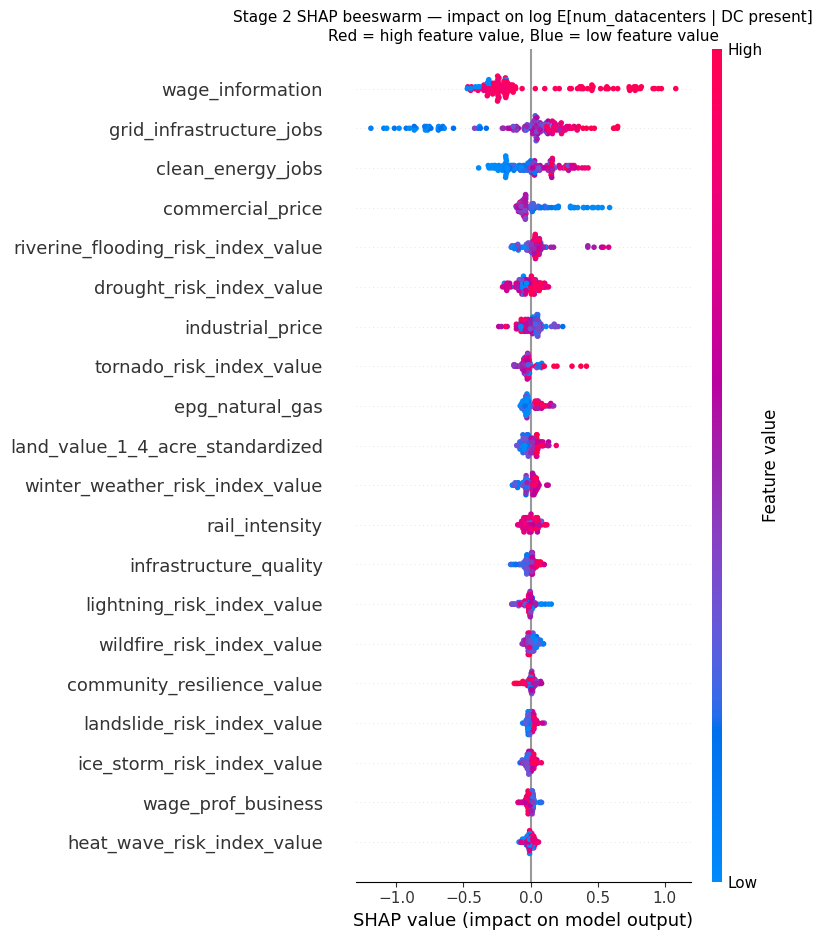

In [7]:
plt.figure(figsize=(10, 7))
shap.summary_plot(sv2, X_test_pos, show=False, max_display=20)
plt.title('Stage 2 SHAP beeswarm — impact on log E[num_datacenters | DC present]\n'
          'Red = high feature value, Blue = low feature value', fontsize=11)
plt.tight_layout()
plt.show()

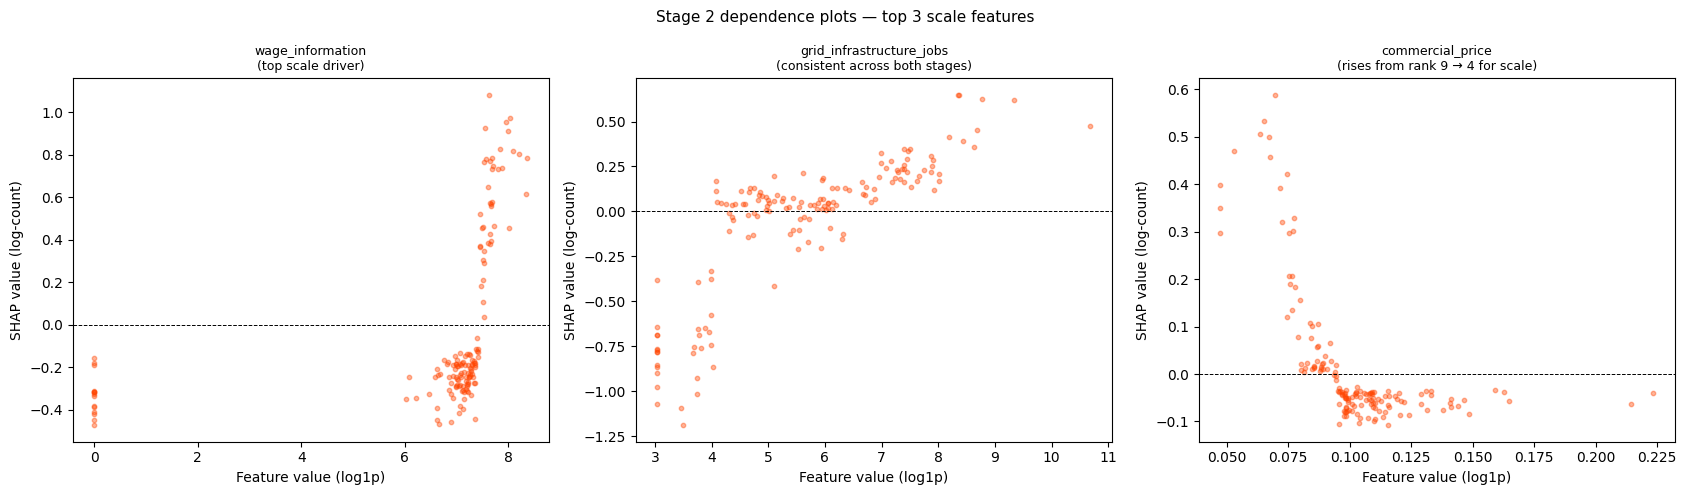

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
top3_s2 = ['wage_information', 'grid_infrastructure_jobs', 'commercial_price']
titles   = ['wage_information\n(top scale driver)',
             'grid_infrastructure_jobs\n(consistent across both stages)',
             'commercial_price\n(rises from rank 9 → 4 for scale)']

for ax, feat, title in zip(axes, top3_s2, titles):
    col_idx = list(X_test_pos.columns).index(feat)
    ax.scatter(X_test_pos[feat].values, sv2[:, col_idx], alpha=0.4, s=10, color='orangered')
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--')
    ax.set_xlabel('Feature value (log1p)')
    ax.set_ylabel('SHAP value (log-count)')
    ax.set_title(title, fontsize=9)

plt.suptitle('Stage 2 dependence plots — top 3 scale features', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Key Divergences Between Presence and Scale

The bump chart below makes the rank shifts between Stage 1 and Stage 2 explicit.
Features that move UP (lower rank number = more important) in Stage 2 are scale
amplifiers; features that DROP OUT are presence-specific signals.

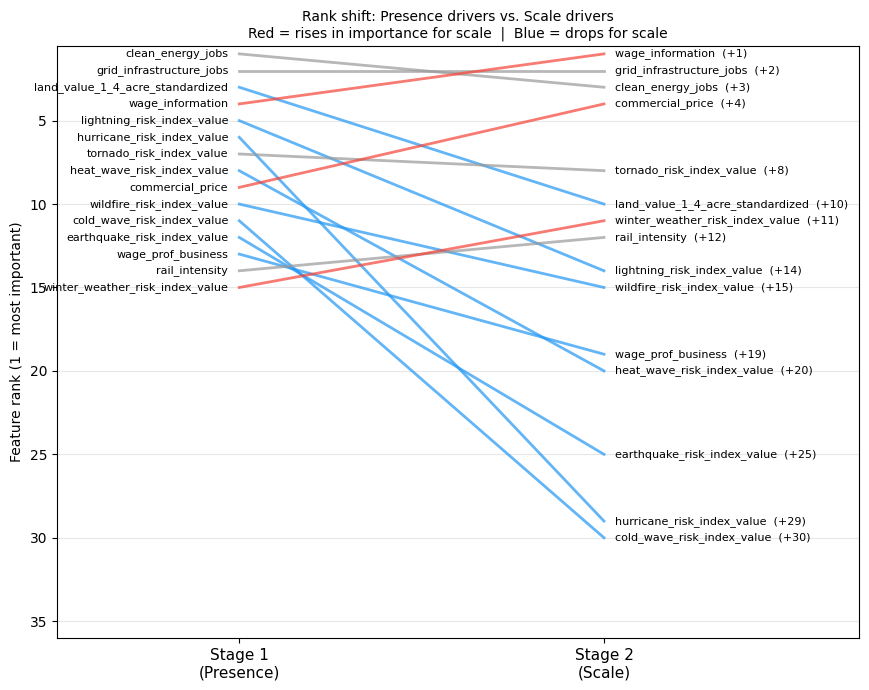

In [9]:
# Bump chart: Stage 1 rank vs Stage 2 rank for top-15 Stage 1 features
TOP_BUMP = 15
feats = list(imp1.head(TOP_BUMP).index)
rank1 = {f: i+1 for i,f in enumerate(imp1.index)}
rank2 = {f: i+1 for i,f in enumerate(imp2.index)}

fig, ax = plt.subplots(figsize=(9, 7))
for feat in feats:
    r1 = rank1[feat]
    r2 = rank2.get(feat, 38)  # 38 = off the chart
    shift = r2 - r1
    color = '#F44336' if shift < -2 else ('#2196F3' if shift > 2 else '#999999')
    ax.plot([0, 1], [r1, r2], color=color, alpha=0.7, linewidth=2)
    ax.text(-0.03, r1, feat, ha='right', va='center', fontsize=8)
    label = f'{feat}  ({r2:+d})' if r2 < 38 else f'{feat}  (>35)'
    ax.text(1.03, r2, label, ha='left', va='center', fontsize=8)

ax.set_xlim(-0.5, 1.7)
ax.set_ylim(0.5, 36)
ax.invert_yaxis()
ax.set_xticks([0, 1])
ax.set_xticklabels(['Stage 1\n(Presence)', 'Stage 2\n(Scale)'], fontsize=11)
ax.set_ylabel('Feature rank (1 = most important)')
ax.set_title('Rank shift: Presence drivers vs. Scale drivers\n'
             'Red = rises in importance for scale  |  Blue = drops for scale', fontsize=10)
ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

**Reading the bump chart:**

| Feature | S1 rank | S2 rank | Pattern |
|---|---|---|---|
| `wage_information` | 4 | 1 | Rises — **agglomeration effect** |
| `commercial_price` | 9 | 4 | Rises — **electricity cost sensitivity at scale** |
| `rail_intensity` | 14 | 12 | Stable — moderate infrastructure signal |
| `grid_infrastructure_jobs` | 2 | 2 | Stable — **consistent across both stages** |
| `clean_energy_jobs` | 1 | 3 | Stable — energy sector remains important |
| `hurricane_risk` | 6 | 29 | Drops — **geographic confounder, not causal** |
| `cold_wave_risk` | 11 | 30 | Drops — geographic confounder |
| `heat_wave_risk` | 8 | 20 | Drops — geographic confounder |
| `earthquake_risk` | 12 | 25 | Drops — geographic confounder |
| `land_value` | 3 | 10 | Drops — **urban density proxy for presence only** |

The core structural story: there are **two distinct mechanisms** at play.

1. **Presence is about infrastructure thresholds**: a county needs to pass a minimum
   bar on power supply, IT labor, and economic density. The hazard risk appearance
   is a geographic artifact of where the existing DC market happens to sit.

2. **Scale is about competitive advantages**: among counties that pass the threshold,
   deeper IT talent (wage_information), lower electricity cost (commercial_price),
   and better grid capacity (grid_infrastructure_jobs) compound to attract more facilities.

## 5. Caveats and Interpretive Limits

### Geographic confounding (hazard risk indices)

The positive SHAP contribution of hazard risk indices in Stage 1 is the most important
caveat. Because `state` was excluded from the model to prevent it from absorbing
structural feature variance, the hazard indices are doing double duty as geographic
proxies. A county in Virginia has high lightning risk AND many data centers — not
because lightning attracts DCs, but because they co-occur geographically. Without
a spatial lag term or state fixed effects, this confounding cannot be removed.

**Practical rule**: treat any hazard risk finding as "describes where DCs currently
are" not "predicts where DCs should be."

### Suppression floor artifacts (energy/jobs features)

The negative mean SHAP for `clean_energy_jobs` and `grid_infrastructure_jobs`
in Stage 1 is a statistical artifact of BEA disclosure suppression (76% and 16%
of counties at floor values). The `*_above_floor` binary indicators capture this
threshold explicitly. The floor-counties should be read as "no significant energy
sector" not as "some specific low level of energy employment."

### Reverse causality (IT wages)

`wage_information` being a top predictor at both stages likely reflects
bidirectional causality: a tech labor market attracts DCs, but DCs also
create and sustain tech jobs. The SHAP value tells you the correlation;
the direction of causation requires external evidence.

### Target construction (fractional counts)

`num_datacenters` is a ZIP-to-county allocated fractional estimate, not
a directly observed county count. Measurement error in the target
attenuates all SHAP magnitudes toward zero — the true feature effects
are likely stronger than what the model captures.

## 6. Implications for Data Center Siting Strategy

Based on the two-stage SHAP analysis, the structural profile of an attractive
county looks different depending on the objective:

### Profile: "First mover" county (no existing DCs)
A county worth targeting for initial siting should have:
1. **Energy sector above suppression floor** — real grid infrastructure employment
   (above BEA floor), signaling sufficient power generation/transmission capacity
2. **IT labor market** — non-zero IT sector wages, even if modest
3. **Economic density** — moderate-to-high land values as a proxy for
   connectivity and infrastructure quality
4. **Low hazard exposure** — while hazard indices are confounded for presence,
   they remain valid risk considerations for actual siting decisions;
   counties with genuinely low NRI scores are preferable all else equal

### Profile: "Scale market" county (existing DC presence)
A county likely to grow into a major hub should additionally have:
1. **Deep IT labor market** — high wage_information, indicating a mature
   tech workforce that can support multi-facility operations
2. **Competitive electricity pricing** — commercial and industrial prices
   below the national median
3. **Grid capacity** — above-floor grid_infrastructure_jobs, natural gas access

### What does NOT appear as a strong structural driver
- **Broadband coverage rates** (`fiber_availability`, `any_tech_1000_100_coverage`)
  rank outside the top 20 in both stages. At the county level, broadband
  coverage is near-universal — it does not discriminate between counties.
  What matters is the physical infrastructure layer (grid, energy), not
  the coverage rate.
- **Policy signals** (`has_policy_signal`, `policy_direction_score`) also rank
  low, consistent with the EDA finding that policy attention often follows
  existing DC activity rather than preceding it.

## 7. County Attractiveness Ranking

We score all 3,138 counties using the combined hurdle prediction:

**score = P(has DC | X) × E[num_datacenters | DC present, X]**

This is the hurdle model's expected count for every county. The ranking captures both
the likelihood of DC presence and the expected scale of the cluster — making it the most
policy-relevant output. Counties are ranked from most to least attractive. The table is
exported to `data_revealed/04_tables/county_attractiveness_ranking.csv`.

In [10]:
prob_all  = stage1.predict_proba(X)[:, 1]
scale_all = stage2.predict(X)
score_all = prob_all * scale_all

ranking = df[['county_key','county','state','county_fips','num_datacenters']].copy()
ranking['p_presence']     = prob_all.round(4)
ranking['expected_scale'] = scale_all.round(4)
ranking['attractiveness'] = score_all.round(4)
ranking = ranking.sort_values('attractiveness', ascending=False).reset_index(drop=True)
ranking.index += 1
ranking.index.name = 'rank'

out_path = 'data_revealed/04_tables/county_attractiveness_ranking.csv'
ranking.to_csv(out_path)
print(f'Saved: {out_path}  ({len(ranking)} rows)')
print('\nTop 20 counties by attractiveness:')
print(ranking[['county','state','num_datacenters','p_presence','expected_scale','attractiveness']].head(20).to_string())

Saved: data_revealed/04_tables/county_attractiveness_ranking.csv  (3138 rows)

Top 20 counties by attractiveness:
                     county       state  num_datacenters  p_presence  expected_scale  attractiveness
rank                                                                                                
1            Loudoun County    Virginia       304.006814      0.9881         19.8875         19.6507
2            Fairfax County    Virginia        48.993186      0.9958         19.0034         18.9230
3     Prince William County    Virginia       111.609509      0.9859         18.0801         17.8243
4             Travis County       Texas        24.432787      0.9990         16.7375         16.7208
5             Dallas County       Texas       125.737553      0.9989         16.7375         16.7189
6        Los Angeles County  California        73.950628      0.9987         16.7375         16.7165
7          San Diego County  California        15.000000      0.9987         1

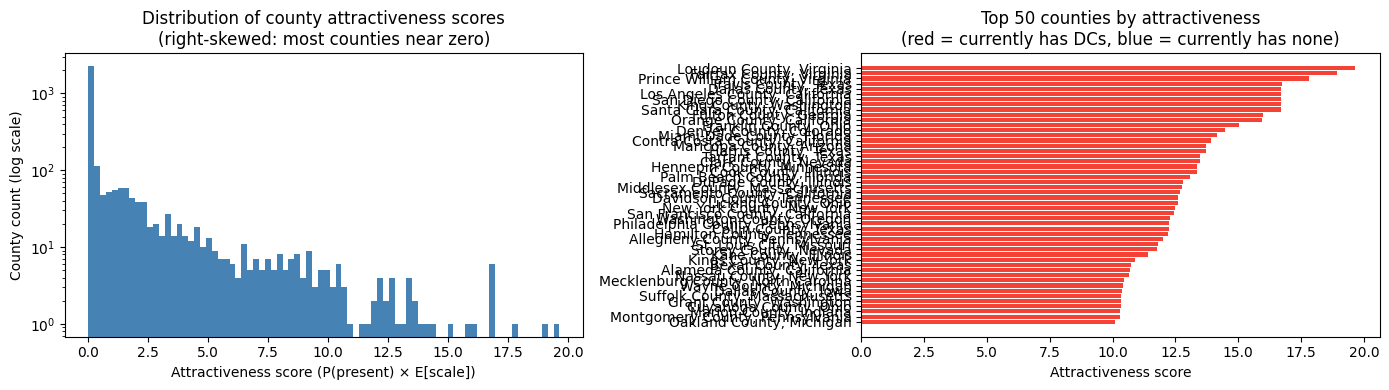

In [11]:
# Distribution of attractiveness scores
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(ranking['attractiveness'], bins=80, color='steelblue', edgecolor='none', log=True)
ax.set_xlabel('Attractiveness score (P(present) × E[scale])')
ax.set_ylabel('County count (log scale)')
ax.set_title('Distribution of county attractiveness scores\n(right-skewed: most counties near zero)')

ax = axes[1]
top50 = ranking.head(50)
ax.barh(top50['county'] + ', ' + top50['state'], top50['attractiveness'],
        color=['#F44336' if dc > 0 else '#2196F3' for dc in top50['num_datacenters']])
ax.invert_yaxis()
ax.set_xlabel('Attractiveness score')
ax.set_title('Top 50 counties by attractiveness\n(red = currently has DCs, blue = currently has none)')

plt.tight_layout()
plt.show()